In [97]:
# notebook magics
# inline/notebook/interactive
%matplotlib notebook
%load_ext autoreload
%autoreload 2

import os, sys
sys.path.append(os.path.abspath("lib")) # N.B: NB needs this line to run locally!!
os.getcwd()
import time
from argparse import Namespace
import numpy as np
import matplotlib.pyplot as plt
import xp as xp
import matplotlib as mpl
import pandas as pd

from IPython.display import display
# make figures higher resolution (larger)
plt.rcParams['figure.dpi'] = 80
# A decent backend for animations
plt.rcParams["animation.html"] = "jshtml"
# let 'em get big
plt.rcParams["animation.embed_limit"] = 80  # MB

# import our code that we need
import os, sys 
sys.path.append(os.path.abspath("lib"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [104]:
test_PS = np.load("test_PS.npz", allow_pickle=True)
print(test_PS.keys())

R = test_PS['R']
P = test_PS['P']

pPS = test_PS['pPS'] # <p_e>(R,P)
psiPSv = test_PS['psiPSv']

print(pPS[:5,:5])
print(xp.sum(xp.abs(pPS.imag)))
print(test_PS.files)

KeysView(NpzFile 'test_PS.npz' with keys: EPS, R, P, rPS, pPS...)
[[0.00080629+0.00000000e+00j 0.00077359+0.00000000e+00j
  0.00074095+0.00000000e+00j 0.00070836+0.00000000e+00j
  0.00067582+1.11022302e-16j]
 [0.00089931+0.00000000e+00j 0.00086279+0.00000000e+00j
  0.00082633-2.22044605e-16j 0.00078994+0.00000000e+00j
  0.00075361-1.04083409e-17j]
 [0.00098644+0.00000000e+00j 0.00094633+0.00000000e+00j
  0.0009063 -5.55111512e-17j 0.00086635+0.00000000e+00j
  0.00082646-5.55111512e-17j]
 [0.00106072+0.00000000e+00j 0.00101757+0.00000000e+00j
  0.00097451-1.11022302e-16j 0.00093153-5.03069808e-17j
  0.00088863+1.11022302e-16j]
 [0.00111274+0.00000000e+00j 0.00106752-5.55111512e-17j
  0.00102238+1.38777878e-17j 0.00097732+5.55111512e-17j
  0.00093234+0.00000000e+00j]]
5.87308522127794e-14
['EPS', 'R', 'P', 'rPS', 'pPS', 'HPS', 'EPSv', 'psiPSv']


In [52]:
print(pPS.shape, psiPSv.shape)

(51, 51) (51, 51)


In [92]:
def electronic_observable_via_inv_wigner(R, P,state0, state1, oPS):
    '''Takes in a R and P grid (shape (R)), vibrational wfc for state0 and 1, shape (R), 
    and <o>(R,P) expectation value of o on the PS ground state surface for every R and P, shape (R,R).'''
    NR = R.size
    dR = R[1]-R[0]
    dP = P[1]-P[0]
    R_half = np.linspace(R[0] - dR/2, R[-1] + dR/2, NR + 1)
    
    exp_iPR = xp.exp(1j * xp.outer(P, R)) # e^(i P. R)
    exp_iPRhalf = xp.exp(1j * xp.outer(P, R_half)) # e^(i P. (R+ dR/2))
    
    def inverse_half_wigner(R, P, state0, state1): 
        ''' W(|0><1) ~ W_{01}(R,P) following eq 62 in Xuezhi's paper, limited case for a projections,
        would need ROI to do arbitrary nuclear opperator'''
        
        ## Interpolate the states to a half step grid, size (NR+1)
        state0_half = (exp_iPRhalf.T.conj()) @ exp_iPR @state0/NR
        state1_half = (exp_iPRhalf.T.conj()) @ exp_iPR @state1/NR

        proj_half = state0_half[1:,None]*state1_half[None,:NR] # <R+dR/2|chi_1 > <chi_2|R-dR/2>

        rho_wigner = np.zeros((NR,NR))
        for i in range(NR): # P loop
            for j in range(NR): # R loop
                for k in range(NR): # R' loop
                    plus = (j+k)%NR
                    minus = (j-k)%NR
                    rho_wigner[j,i] = exp_iPR[i,k]*proj_half[plus, minus]
        return rho_wigner
    return xp.sum(oPS*Wigner)
        
        

(102,)
(51, 51) (51, 52) (52,)
wigner (51, 51)
(1.0666413888024788e-09-0.0207994077612422j)


<IPython.core.display.Javascript object>

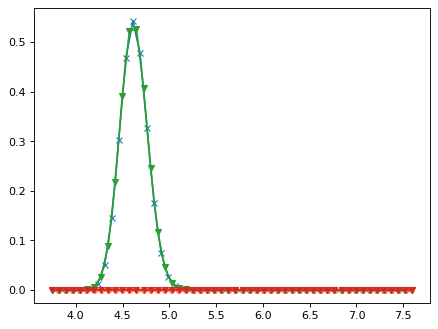

In [115]:
state0 = psiPSv[:,0]
state1 = psiPSv[:,1]
# state0_k = xp.fft.fft(state0)

state0_half = np.zeros((2*NR))
print(state0_half.shape)

NR = R.size
dR = R[1]-R[0]
dP = P[1]-P[0]
R_half = np.linspace(R[0] - dR/2, R[-1] + dR/2, NR + 1)

exp_iPR = xp.exp(1j * xp.outer(P, R))
exp_iPRhalf = xp.exp(1j * xp.outer(P, R_half))

state0_half = (exp_iPRhalf.T.conj()) @ exp_iPR @state0/NR
state1_half = (exp_iPRhalf.T.conj()) @ exp_iPR @state1/NR

print(exp_iPR.shape, exp_iPRhalf.shape, state0_half.shape)

proj_half = state0_half[:NR,None]*state1_half[None,1:]
print("wigner", Wigner.shape)

Wigner = np.zeros((NR,NR), dtype=xp.complex128)
for i in range(NR): # P loop
    for j in range(NR): # R loop
        for k in range(NR): # R' loop
            plus = (j+k)%NR
            minus = (j-k)%NR
            Wigner[j,i] = exp_iPR[i,k]*proj_half[plus, minus]


print(xp.sum(Wigner*pPS))


fig,ax = plt.subplots()
plt.plot(R, -1*state0, '-x')
plt.plot(R, -1*state0.imag, '-x')
plt.plot(R_half, -1*state0_half, '-v')


display(fig)

In [113]:
from hamiltonian import inverse_weyl_transform

pRR = inverse_weyl_transform(pPS, NR, R, P)
print(pRR.dtype, state0.dtype)
print("hermite", xp.sum(xp.abs(pRR.conj().T-pRR)))

print(xp.sum(state0.conj()*pRR@state1))
print(xp.sum(state0*pRR@(state1.conj())))

print(electronic_observable_via_inv_wigner(R,P,state0, state1, pPS))

complex128 complex128
hermite 4.412503040262025e-14
(4.292541274935442e-10+0.00024664626485017364j)
(4.292940913552737e-10+0.00024664626485017385j)
(1.0666413888024788e-09-0.0207994077612422j)


In [96]:
print(pRR[:5,:5])

[[-4.36579748e-12+4.48987253e-18j -1.62537377e-07-8.83642883e-02j
  -3.13759696e-13+1.46223046e-04j  1.15547153e-08+1.61966129e-02j
  -1.62112392e-13+8.08853589e-05j]
 [-1.62537377e-07+8.83642883e-02j -7.84073586e-12-1.56465255e-17j
   8.92104965e-08+4.85231582e-02j -6.59659125e-13+1.60377324e-04j
  -7.90021911e-09-1.13032791e-02j]
 [-3.13751463e-13-1.46223046e-04j  8.92104965e-08-4.85231582e-02j
  -1.01796235e-11-5.44226973e-19j -6.09179549e-08-3.38581380e-02j
  -1.21811490e-12+1.72449770e-04j]
 [ 1.15547153e-08-1.61966129e-02j -6.59654145e-13-1.60377324e-04j
  -6.09179549e-08+3.38581380e-02j -1.14053170e-11-7.06219533e-18j
   4.62289436e-08+2.51677308e-02j]
 [-1.62127849e-13-8.08853589e-05j -7.90021914e-09+1.13032791e-02j
  -1.21812251e-12-1.72449770e-04j  4.62289436e-08-2.51677308e-02j
  -1.39789553e-11-5.85043996e-18j]]


In [109]:
print(xp.sum(xp.abs(test_PS['HPS'].T.conj()-test_PS['HPS'])))


2.0039386774702465e-16


In [119]:
with xp.printoptions(precision=6, suppress=True, linewidth=xp.inf):
    print(pPS[:5,:5])
    print(pPS[:5,-5:])

[[0.000806+0.j 0.000774+0.j 0.000741+0.j 0.000708+0.j 0.000676+0.j]
 [0.000899+0.j 0.000863+0.j 0.000826-0.j 0.00079 +0.j 0.000754-0.j]
 [0.000986+0.j 0.000946+0.j 0.000906-0.j 0.000866+0.j 0.000826-0.j]
 [0.001061+0.j 0.001018+0.j 0.000975-0.j 0.000932-0.j 0.000889+0.j]
 [0.001113+0.j 0.001068-0.j 0.001022+0.j 0.000977+0.j 0.000932+0.j]]
[[-0.000676+0.j -0.000708+0.j -0.000741+0.j -0.000774+0.j -0.000806+0.j]
 [-0.000754-0.j -0.00079 -0.j -0.000826-0.j -0.000863+0.j -0.000899+0.j]
 [-0.000826+0.j -0.000866+0.j -0.000906+0.j -0.000946+0.j -0.000986-0.j]
 [-0.000889+0.j -0.000932-0.j -0.000975-0.j -0.001018+0.j -0.001061+0.j]
 [-0.000932+0.j -0.000977+0.j -0.001022-0.j -0.001068+0.j -0.001113+0.j]]


In [121]:
with xp.printoptions(precision=6, suppress=True, linewidth=xp.inf):
    print(test_PS['EPS'][:5,:5])
    print(test_PS['EPS'][:5,-5:])

[[0.064313 0.060757 0.057345 0.054079 0.050958]
 [0.050052 0.046497 0.043087 0.039822 0.036702]
 [0.037613 0.034059 0.030651 0.027387 0.024268]
 [0.026967 0.023415 0.020007 0.016745 0.013628]
 [0.018038 0.014488 0.011082 0.007822 0.004706]]
[[0.050958 0.054079 0.057345 0.060757 0.064313]
 [0.036702 0.039822 0.043087 0.046497 0.050052]
 [0.024268 0.027387 0.030651 0.034059 0.037613]
 [0.013628 0.016745 0.020007 0.023415 0.026967]
 [0.004706 0.007822 0.011082 0.014488 0.018038]]
